# Example: Getting the analytical window for the geometry of the LRG autocorrelation

This example notebook was run on a shared GPU node at NERSC (one GPU and about 10GB of memory). 

In [1]:
import itertools
from pathlib import Path

import healpy as hp
import jax
import jax.numpy as jnp
import lsstypes as lss
import matplotlib.pyplot as plt
import numpy as np
from jaxpower import BinMesh2SpectrumPoles, FKPField, compute_fkp2_normalization, get_mesh_attrs
from tqdm import tqdm

from desiwinds.convenience import fiducial_planck_2018, get_randoms, get_sysmap, split_into_fields
from desiwinds.forward import mock_survey_catalog
from desiwinds.window import get_window_geometry


## Parameters
Adjust data paths and redshift ranges to match your environment.

In [2]:
LOS = "local"
UNITARY_AMPLITUDE = True
nreal_fw = 20

n_randoms = 1

boxsize = 8000.0
cellsize = 40.0

tracer = "LRG"
z_range = (0.4, 1.1) # (0.4, 0.8)  # Thin-ish slice to speed up the example (limited compute resources)

pk_regions = ["SGC", "NGC"]
photo_regions = ["N", "S"]  # Photometric regions for LRG
z_ranges = [(0.4, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.0), (1.0, 1.1)]  # Redshift ranges for the angular systematics regression

data_to_randoms = 0.3 # Use 30% of the randoms catalogs as "data" and the rest as randoms

randoms_basedir = Path("/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/fNL")

## Load randoms and create catalogs

### Randoms catalogs

In [3]:
fkp_fields = []
fkp_norms = []

data = []
randoms = []

for pk_region in pk_regions:
    # Load data for single tracer
    position, [weight] = get_randoms(
        n_randoms,
        pk_region,
        z_range,
        tracer,
        "default",
        basedir=randoms_basedir,
        return_redshift=False,
    )

    # Create mesh attributes
    mattrs = get_mesh_attrs(position, cellsize=cellsize, boxsize=boxsize, check=True)

    # Create data/randoms split
    _data, _randoms, _mask_is_data = split_into_fields(
        position,
        weight,
        extra=None,
        data_size=int(weight.shape[0] * data_to_randoms),
        split_seed=123,
        mattrs=mattrs,
        exchange=True,
        backend="jax",
    )

    data.append(_data)
    randoms.append(_randoms)

    # Create FKP field
    fkp_field = FKPField(data=_data, randoms=_randoms, attrs=mattrs)
    fkp_fields.append(fkp_field)

    # Compute normalization
    binner = BinMesh2SpectrumPoles(mattrs=mattrs, edges={"min": 0.005, "step": 0.005}, ells=(0, 2, 4))
    fkp_norm = compute_fkp2_normalization(fkp_field, bin=binner, cellsize=10.0)
    fkp_norms.append(fkp_norm)

    del position, weight, _mask_is_data, _data, _randoms

In [4]:
theory = fiducial_planck_2018(jnp.arange(0.0, jnp.pi / cellsize, 0.005))

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/code/cosmoprimo/main/lib/python3.12/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


## Get analytical window

In [5]:
windows_analytical = []
for _data, _randoms in zip(data, randoms):
    data_mesh = _data.paint(resampler="tsc", interlacing=3, compensate=True)
    randoms_mesh = _randoms.paint(resampler="tsc", interlacing=3, compensate=True)
    windows_analytical.append(get_window_geometry(
        selection2=data_mesh,
        selection1=_data.sum() / _randoms.sum() * randoms_mesh,  # tsc
        theory_edges=theory,
        theory_ells=theory.ells,
        binner=binner,
        norm=fkp_norm,  # cic
        flags=(),
        los=LOS,
        pbar=True,
    ))

100%|█████████▉| 15/15 [00:30<00:00,  2.01s/it]


## Forward level for comparison

In [6]:
fw_jit = jax.jit(mock_survey_catalog, static_argnames=["los", "unitary_amplitude", "estimator_weights"])
fw_nojit = mock_survey_catalog

In [7]:
pks_geo = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=None,
        amr_args=None,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        estimator_weights=None,
        data_regions=None,
        randoms_regions=None,
    )
    for i in tqdm(range(nreal_fw), desc="Geometry forward modeling")
]

Geometry forward modeling: 100%|██████████| 20/20 [00:14<00:00,  1.37it/s]


Text(0.5, 1.0, 'Geometry-only power spectrum')

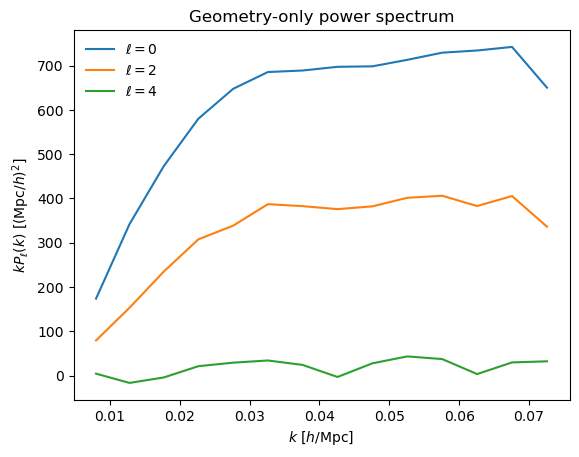

In [8]:
lss.mean(list(map(sum, pks_geo))).plot()
plt.title("Geometry-only power spectrum")

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


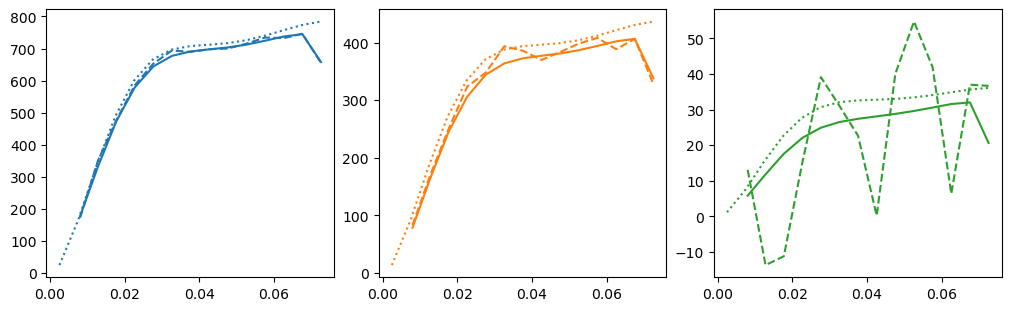

In [9]:
isurvey = 1 # NGC

fig, lax = plt.subplots(1, 3, figsize=(10, 3), layout="constrained", sharex=True)

windowed_theory = windows_analytical[isurvey].dot(theory, return_type=None, zpt=False)

for ell, ax in zip([0, 2, 4], lax):
    pole_th = theory.get(ell)
    pole_wd = windowed_theory.get(ell)
    pole_fm = lss.mean([_pks_geo[isurvey] for _pks_geo in pks_geo]).get(ell)
    ax.plot(k:=pole_th.coords("k"), k*pole_th.value(), color=f"C{ell//2}", ls=':')
    ax.plot(k:=pole_wd.coords("k"), k*pole_wd.value(), color=f"C{ell//2}", ls='-')
    ax.plot(k:=pole_fm.coords("k"), k*pole_fm.value(), color=f"C{ell//2}", ls='--')